In [7]:
import numpy as np
import matplotlib.pyplot as plt
# numpy : manipulation des tableaux numériques et effectuer des calculs mathématiques rapidement.
# matplotlib : affichage des graphiques

Prédictions : [0 0 0 1 1 1]
Accuracy : 1.0


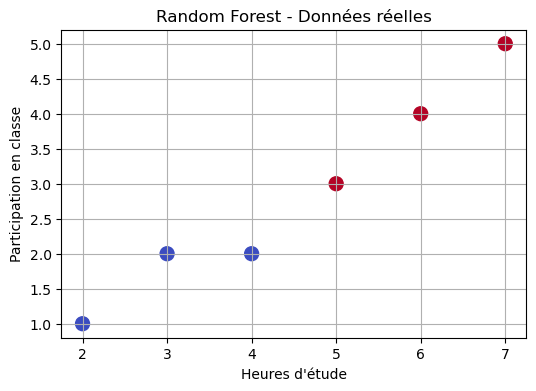

In [6]:
# RANDOM FOREST - Classification supervisée from SCRATCH
# ================================
# 1. Dataset
# ================================

X = np.array([
    [2, 1],
    [3, 2],
    [4, 2],
    [5, 3],
    [6, 4],
    [7, 5]
])
# X représente les variables d’entrée (features)
# Colonne 1 : heures d’étude
# Colonne 2 : participation en classe

y = np.array([0, 0, 0, 1, 1, 1])
# y représente la sortie réelle :
# 0 = échec
# 1 = réussite

# ================================
# 2. "Arbre" simplifié
# ================================

def simple_tree(x):
    """
    Simulation d’un arbre de décision très simple.
    On utilise une règle fixe basée sur un seuil.
    """

    score = x[0] + x[1]
    # On combine les deux variables pour créer un score

    if score > 6:
        return 1
        # score élevé → réussite
    else:
        return 0
        # score faible → échec

# ================================
# 3. Random Forest (simulation)
# ================================

def random_forest(X):
    """
    Une Random Forest est un ensemble d’arbres.
    Chaque arbre fait une prédiction.
    Ensuite on fait un vote majoritaire.
    """

    predictions = []

    for x in X:
        votes = []

        for i in range(5):
            # chaque arbre donne une prédiction
            votes.append(simple_tree(x))

        # vote majoritaire (classe la plus fréquente)
        final_pred = max(set(votes), key=votes.count)
        predictions.append(final_pred)

    return np.array(predictions)

# ================================
# 4. Prédictions
# ================================

y_pred = random_forest(X)

print("Prédictions :", y_pred)

# ================================
# 5. Accuracy
# ================================

accuracy = np.mean(y_pred == y)
# comparaison entre vrai et prédit

print("Accuracy :", accuracy)

# ================================
# 6. Graphe
# ================================

plt.figure(figsize=(6,4))
# Création de la figure (graphique)

plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=100)
# Affichage des données réelles
# Chaque point représente un étudiant
# Couleur :
# 0 = échec
# 1 = réussite

plt.xlabel("Heures d'étude")
# Axe X : heures d'étude

plt.ylabel("Participation en classe")
# Axe Y : participation

plt.title("Random Forest - Données réelles")
# Titre du graphique

plt.grid(True)
# Ajout d’une grille pour faciliter la lecture

plt.show()
# Affichage du graphique

Meilleure feature : 0
Meilleur seuil : 3
Prédiction : 1


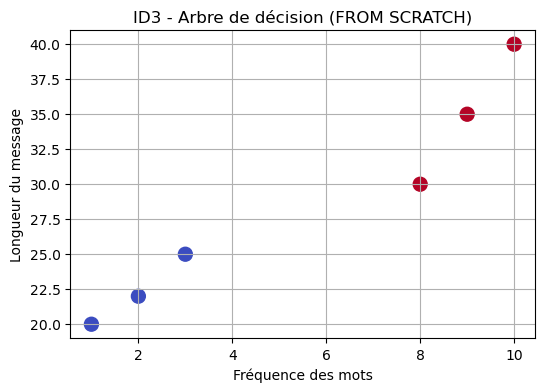

In [9]:
# ID3 - Arbre de décision From SCRATCH


# ================================
# 1. Dataset
# ================================

X = np.array([
    [1, 20],
    [2, 22],
    [3, 25],
    [8, 30],
    [9, 35],
    [10, 40]
])
# X représente les variables d’entrée (features).
# Chaque ligne correspond à un exemple (ici un message).
#
# Colonne 1 : fréquence de certains mots dans le message.
# Colonne 2 : longueur du message.
#
# Ces variables sont utilisées pour décider si un message est spam ou non.

y = np.array([0, 0, 0, 1, 1, 1])
# y représente les étiquettes (labels).
# 0 = message normal
# 1 = message spam
# Le modèle va apprendre à relier X → y.

# ================================
# 2. Fonction d’entropie (ID3)
# ================================

def entropy(y):
    """
    L’entropie mesure le niveau de désordre dans les données.
    - Si les données sont mélangées → entropie élevée
    - Si elles sont bien séparées → entropie faible
    """

    values, counts = np.unique(y, return_counts=True)
    # values = classes uniques (ex: 0 et 1)
    # counts = nombre d’occurrences de chaque classe

    probs = counts / len(y)
    # calcul de la probabilité de chaque classe

    return -np.sum(probs * np.log2(probs))
    # formule mathématique de l’entropie
    # utilisée dans ID3 pour mesurer la pureté d’un groupe

# ================================
# 3. Fonction de séparation (split)
# ================================

def split(X, y, feature_index, threshold):
    """
    Cette fonction divise les données en 2 groupes :
    - gauche : valeurs <= seuil
    - droite : valeurs > seuil
    """

    left_mask = X[:, feature_index] <= threshold
    # sélection des lignes où la valeur est <= seuil

    right_mask = X[:, feature_index] > threshold
    # sélection des lignes où la valeur est > seuil

    return y[left_mask], y[right_mask]
    # on retourne uniquement les labels correspondants

# ================================
# 4. Recherche du meilleur split
# ================================

def best_split(X, y):
    """
    Cette fonction teste toutes les possibilités
    et choisit la meilleure séparation possible
    selon le gain d’information.
    """

    best_gain = -1
    # meilleure amélioration trouvée jusqu’ici

    best_feature = None
    # feature (colonne) la plus importante

    best_threshold = None
    # seuil optimal pour séparer les données

    base_entropy = entropy(y)
    # entropie avant séparation

    for feature in range(X.shape[1]):
        # on teste chaque colonne (feature)

        thresholds = np.unique(X[:, feature])
        # on teste tous les seuils possibles

        for t in thresholds:

            y_left, y_right = split(X, y, feature, t)
            # séparation des données

            if len(y_left) == 0 or len(y_right) == 0:
                continue
                # on ignore les séparations invalides

            p_left = len(y_left) / len(y)
            p_right = len(y_right) / len(y)
            # proportion de chaque groupe

            gain = base_entropy - (
                p_left * entropy(y_left) +
                p_right * entropy(y_right)
            )
            # gain d’information :
            # plus il est grand → meilleure séparation

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = t
                # on garde la meilleure séparation trouvée

    return best_feature, best_threshold
    # retourne la meilleure règle de décision

# ================================
# 5. Construction de l’arbre (1 niveau)
# ================================

feature, threshold = best_split(X, y)
# on récupère la meilleure feature et le meilleur seuil

print("Meilleure feature :", feature)
print("Meilleur seuil :", threshold)

# ================================
# 6. Prédiction
# ================================

def predict(x):
    """
    Fonction de prédiction basée sur la règle trouvée.
    """

    if x[feature] <= threshold:
        return 0
        # classe 0 = normal
    else:
        return 1
        # classe 1 = spam

print("Prédiction :", predict([9, 32]))
# test d’un nouvel exemple

# ================================
# 7. Graphe
# ================================

plt.figure(figsize=(6,4))
# création de la figure

plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=100)
# affichage des données
# couleur = classe réelle

plt.xlabel("Fréquence des mots")
# axe X

plt.ylabel("Longueur du message")
# axe Y

plt.title("ID3 - Arbre de décision (FROM SCRATCH)")
# titre du graphique

plt.grid(True)
# grille pour mieux lire le graphe

plt.show()
# affichage final

Meilleur seuil trouvé : 4
Prédiction pour 6h : 1


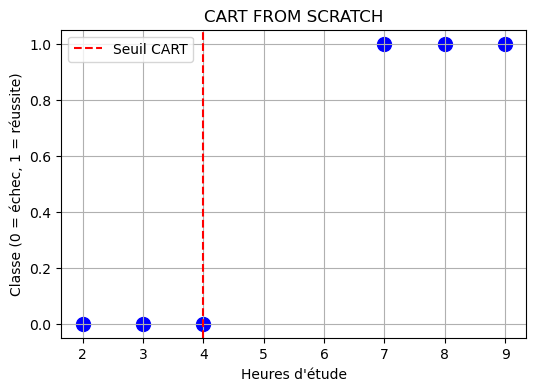

In [11]:
# CART - Arbre de décision From SCRATCH

# ================================
# 1. Dataset
# ================================

X = np.array([
    [2],
    [3],
    [4],
    [7],
    [8],
    [9]
])
# X représente la variable d’entrée (feature).
# Ici, chaque valeur correspond au nombre d’heures d’étude.
# Chaque ligne = un étudiant.

y = np.array([0, 0, 0, 1, 1, 1])
# y représente la variable cible (label).
# 0 = échec
# 1 = réussite
# Le modèle doit apprendre la relation entre X et y.

# ================================
# 2. Fonction Gini (CART)
# ================================

def gini(y):
    """
    L’indice de Gini mesure l’impureté d’un groupe de données.

    - Gini = 0 → groupe parfaitement pur (une seule classe)
    - Gini élevé → mélange de classes
    """

    classes, counts = np.unique(y, return_counts=True)
    # classes : les différentes classes présentes (0 et 1)
    # counts : nombre d’apparitions de chaque classe

    probs = counts / len(y)
    # calcul de la probabilité de chaque classe

    return 1 - np.sum(probs ** 2)
    # formule du Gini :
    # Gini = 1 - somme des probabilités au carré

# ================================
# 3. Fonction de séparation (split)
# ================================

def split(X, y, threshold):
    """
    Cette fonction divise les données en deux groupes :

    - groupe gauche : valeurs <= seuil
    - groupe droit : valeurs > seuil
    """

    left_mask = X[:, 0] <= threshold
    # sélection des lignes où la valeur est inférieure ou égale au seuil

    right_mask = X[:, 0] > threshold
    # sélection des lignes où la valeur est supérieure au seuil

    return y[left_mask], y[right_mask]
    # on retourne uniquement les labels correspondants aux deux groupes

# ================================
# 4. Recherche du meilleur seuil CART
# ================================

def best_split(X, y):
    """
    Cette fonction cherche automatiquement
    le meilleur seuil de séparation.

    Objectif :
    → minimiser l’impureté (Gini)
    """

    best_gini = 999
    # valeur initiale très grande pour pouvoir la minimiser

    best_threshold = None
    # seuil optimal (pas encore trouvé)

    for threshold in np.unique(X[:, 0]):
        # on teste tous les seuils possibles (valeurs uniques)

        y_left, y_right = split(X, y, threshold)
        # on divise les données selon le seuil

        if len(y_left) == 0 or len(y_right) == 0:
            continue
            # on ignore les séparations invalides

        g_left = gini(y_left)
        # Gini du groupe gauche

        g_right = gini(y_right)
        # Gini du groupe droit

        # moyenne pondérée des impuretés
        weight = len(y_left)/len(y) * g_left + len(y_right)/len(y) * g_right

        if weight < best_gini:
            # si cette séparation est meilleure
            best_gini = weight
            best_threshold = threshold
            # on sauvegarde le meilleur seuil

    return best_threshold
    # retourne la meilleure règle de séparation

# ================================
# 5. Construction de l’arbre (1 niveau)
# ================================

threshold = best_split(X, y)
# on calcule le meilleur seuil automatiquement

print("Meilleur seuil trouvé :", threshold)
# affichage du seuil optimal

# ================================
# 6. Fonction de prédiction
# ================================

def predict(x):
    """
    Cette fonction applique la règle de décision trouvée.

    Si x <= seuil → classe 0
    Sinon → classe 1
    """

    if x <= threshold:
        return 0
        # prédiction = échec
    else:
        return 1
        # prédiction = réussite

# test du modèle
print("Prédiction pour 6h :", predict(6))

# ================================
# 7. Graphe
# ================================

plt.figure(figsize=(6,4))
# création de la figure

plt.scatter(X[:,0], y, color="blue", s=100)
# affichage des données réelles
# chaque point = un étudiant

plt.axvline(threshold, color="red", linestyle="--", label="Seuil CART")
# ligne verticale rouge :
# représente la séparation trouvée par l’algorithme

plt.xlabel("Heures d'étude")
# axe horizontal

plt.ylabel("Classe (0 = échec, 1 = réussite)")
# axe vertical

plt.title("CART FROM SCRATCH")
# titre du graphique

plt.legend()
# affiche la légende

plt.grid(True)
# affiche une grille pour faciliter la lecture

plt.show()
# affichage final du graphique

Meilleure feature : 0
Meilleur seuil : 3
Prédiction : 1


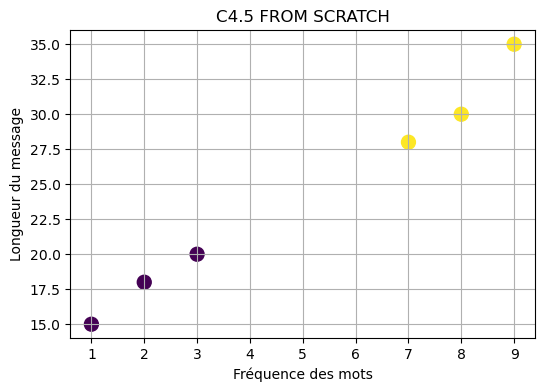

In [13]:
# C4.5 - Arbre de décision


import numpy as np
import matplotlib.pyplot as plt

# ================================
# 1. Dataset
# ================================

X = np.array([
    [1, 15],
    [2, 18],
    [3, 20],
    [7, 28],
    [8, 30],
    [9, 35]
])
# X représente les variables d’entrée (features)
# chaque ligne = un exemple (un message)
# colonne 1 : fréquence de certains mots dans le message
# colonne 2 : longueur du message
# ces deux informations vont servir à prédire si un message est spam ou non

y = np.array([0, 0, 0, 1, 1, 1])
# y représente la variable cible (classe réelle)
# 0 = message normal
# 1 = message spam
# le modèle doit apprendre la relation entre X et y

# ================================
# 2. Fonction Entropie
# ================================

def entropy(y):
    """
    L’entropie mesure le désordre ou l’impureté des données.

    - entropie = 0 → toutes les données appartiennent à une seule classe (pur)
    - entropie élevée → données mélangées (impure)
    """

    values, counts = np.unique(y, return_counts=True)
    # values = classes uniques (0 et 1)
    # counts = nombre d’occurrences de chaque classe

    probs = counts / len(y)
    # calcul des probabilités de chaque classe

    return -np.sum(probs * np.log2(probs))
    # formule mathématique de l’entropie (Shannon entropy)
    # elle mesure le niveau de désordre dans les données

# ================================
# 3. Fonction de séparation (split)
# ================================

def split(X, y, feature, threshold):
    """
    Cette fonction divise les données en deux groupes :

    - groupe gauche : valeurs <= seuil
    - groupe droite : valeurs > seuil

    Cela permet de tester différentes règles de décision.
    """

    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    # left_mask : filtre pour sélectionner les données à gauche du seuil
    # right_mask : filtre pour sélectionner les données à droite du seuil

    return y[left_mask], y[right_mask]

# ================================
# 4. Mesure supplémentaire C4.5 (Intrinsic Value)
# ================================

def intrinsic_value(y_left, y_right):
    """
    C4.5 ajoute une pénalité pour éviter les splits trop faciles ou biaisés.

    Cette fonction mesure la "quantité d'information" créée par la séparation.
    """

    total = len(y_left) + len(y_right)

    p_left = len(y_left) / total
    p_right = len(y_right) / total

    iv = 0

    # on calcule une entropie sur la répartition gauche/droite
    if p_left > 0:
        iv -= p_left * np.log2(p_left)
    if p_right > 0:
        iv -= p_right * np.log2(p_right)

    return iv
    # plus le split est déséquilibré, plus la pénalité est forte

# ================================
# 5. Recherche du meilleur split (C4.5)
# ================================

def best_split(X, y):
    """
    Cette fonction cherche la meilleure règle de séparation :

    Exemple :
    - fréquence <= 5 ?
    - longueur <= 20 ?
    """

    best_ratio = -1
    best_feature = None
    best_threshold = None

    base_entropy = entropy(y)
    # entropie avant séparation (état initial)

    for feature in range(X.shape[1]):
        # on teste chaque colonne (feature)

        thresholds = np.unique(X[:, feature])
        # on teste tous les seuils possibles

        for t in thresholds:

            y_left, y_right = split(X, y, feature, t)

            if len(y_left) == 0 or len(y_right) == 0:
                continue
                # on ignore les splits invalides

            # entropie après séparation
            p_left = len(y_left) / len(y)
            p_right = len(y_right) / len(y)

            new_entropy = p_left * entropy(y_left) + p_right * entropy(y_right)

            # gain d’information = réduction d’entropie
            gain = base_entropy - new_entropy

            # pénalité C4.5 (évite surapprentissage)
            iv = intrinsic_value(y_left, y_right)

            if iv == 0:
                continue

            gain_ratio = gain / iv
            # C4.5 utilise le gain ratio (amélioration de ID3)

            # on garde le meilleur split
            if gain_ratio > best_ratio:
                best_ratio = gain_ratio
                best_feature = feature
                best_threshold = t

    return best_feature, best_threshold

# ================================
# 6. Construction de l’arbre (1 niveau)
# ================================

feature, threshold = best_split(X, y)

print("Meilleure feature :", feature)
print("Meilleur seuil :", threshold)

# on obtient la règle la plus optimale :
# si X[feature] <= threshold → classe 0
# sinon → classe 1

# ================================
# 7. Prédiction
# ================================

def predict(x):
    """
    Cette fonction applique la règle apprise par l’arbre.

    Elle simule une décision simple :
    """

    if x[feature] <= threshold:
        return 0
    else:
        return 1

print("Prédiction :", predict([8, 32]))

# ================================
# 8. graphe
# ================================

plt.figure(figsize=(6,4))

plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", s=100)
# affichage des données réelles
# couleur = classe (spam ou normal)

plt.xlabel("Fréquence des mots")
plt.ylabel("Longueur du message")
plt.title("C4.5 FROM SCRATCH")

plt.grid(True)
plt.show()